Built a movie recommendation engine comparing collaborative filtering approaches (User-CF, Item-CF) and matrix factorization (PMF/SVD) on 100K MovieLens ratings. Tuned similarity metrics and neighbor counts to minimize RMSE. Best model: Item-CF with cosine similarity at k=40.

In [1]:
!pip install scikit-surprise

In [2]:
!pip install numpy==1.24.3

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.3/17.3 MB 69.2 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 1.26.4
    Uninstalling numpy-1.26.4:
      Successfully uninstalled numpy-1.26.4
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.12.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
mkl-umath 0.1.1 requires numpy<1.27.0,>=1.26.4, but you have numpy 1.24.3 which is incompatible.
mkl-random 1.2.4 requires numpy<1.27.0,>=1.26.4, but you have numpy 1.24.3 which is incompatible.
mkl-fft 1.3.8 requires numpy<1.27.0,>=1.26.4, but you have numpy 1.24.3 which is incompatible.
datasets 4.4.1 requires pyarrow>=21.0.0, but you have pyarrow 19.0.1 which is incompatible.
woodwork 0.31.0 requires numpy>=1.25.0, but you have numpy 1.24.3 which is incompatible.
mne 1.10.2 requires numpy<3,


TASK 2 – Baseline Models
Model         RMSE     MAE
PMF (SVD)     0.9922  0.7614
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
User‑CF       0.9959  0.7684
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Item‑CF       1.0050  0.7838
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine sim

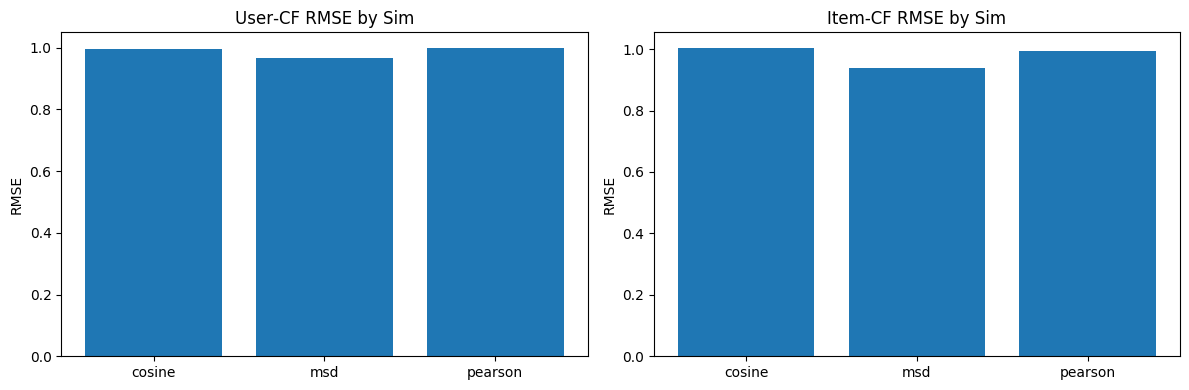

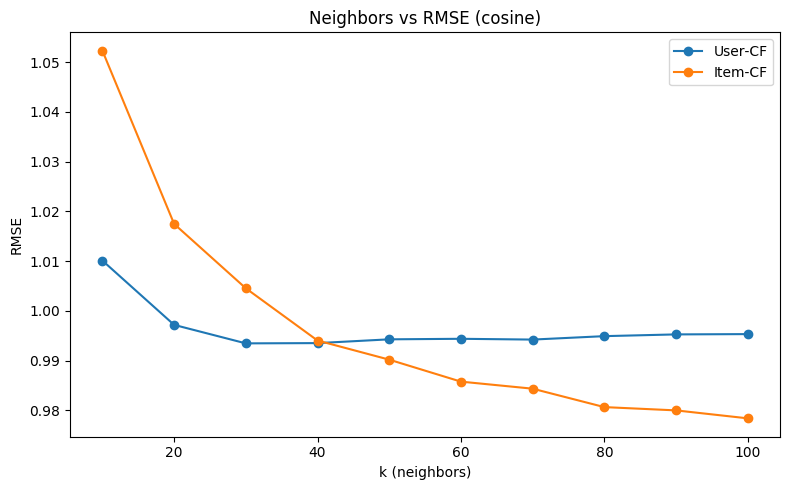

In [3]:

import os
import time
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from surprise import Dataset, Reader, SVD, KNNBasic
from surprise.model_selection import cross_validate

# ─────────────────────────────────────────────────────────────────────────────
#                                 TASK 2
# ─────────────────────────────────────────────────────────────────────────────

def run_task2():
    # pip install scikit-surprise


    # load ratings
    # df = pd.read_csv('ratings_small.csv')
    # reader = Reader(line_format='userId movieId rating timestamp', sep=',')
    # data = Dataset.load_from_df(ratings[['userId','movieId','rating','timestamp']], reader)

    df = pd.read_csv('/kaggle/input/the-movies-dataset/ratings_small.csv')

    # Correct Reader
    reader = Reader(rating_scale=(0.5, 5.0))

    # Load correct 3-column format
    data = Dataset.load_from_df(df[['userId', 'movieId', 'rating']], reader)

    def eval_algo(algo, cv=5):
        out = cross_validate(algo, data, measures=['rmse','mae'], cv=cv, verbose=False)
        return np.mean(out['test_rmse']), np.mean(out['test_mae'])

    # 2.c: PMF (unbiased SVD), User-CF, Item-CF
    algorithms = {
        'PMF (SVD)':      SVD(biased=False, n_factors=50, random_state=42),
        'User‑CF':        KNNBasic(sim_options={'name':'cosine','user_based':True},  k=30),
        'Item‑CF':        KNNBasic(sim_options={'name':'cosine','user_based':False}, k=30),
    }
    print("\nTASK 2 – Baseline Models")
    print("Model         RMSE     MAE")
    for name, algo in algorithms.items():
        rmse, mae = eval_algo(algo)
        print(f"{name:<12}{rmse:8.4f}{mae:8.4f}")

    # 2.e: similarity metrics impact
    sims = ['cosine','msd','pearson']
    sim_results = []
    for name in sims:
        for ub in [True, False]:
            title = f"{'User' if ub else 'Item'}‑CF ({name})"
            algo = KNNBasic(sim_options={'name':name,'user_based':ub}, k=30)
            rmse, mae = eval_algo(algo)
            sim_results.append((title, rmse, mae))

    # plot RMSE for sim metrics
    fig, ax = plt.subplots(1,2, figsize=(12,4))
    for i, ub in enumerate([True, False]):
        subset = [r for r in sim_results if ('User' if ub else 'Item') in r[0]]
        names = [r[0].split('(')[1][:-1] for r in subset]
        rmses = [r[1] for r in subset]
        ax[i].bar(names, rmses)
        ax[i].set_title(f"{'User' if ub else 'Item'}‑CF RMSE by Sim")
        ax[i].set_ylabel('RMSE')
    plt.tight_layout()
    plt.savefig('task2_sim_impact.png', dpi=150)
    print("\nSimilarity impact plot saved to task2_sim_impact.png")

    # 2.f & 2.g: neighbors impact
    ks = list(range(10,101,10))
    neigh_results = {'User':[], 'Item':[]}
    for k in ks:
        for ub in [True, False]:
            algo = KNNBasic(sim_options={'name':'cosine','user_based':ub}, k=k)
            rmse, mae = eval_algo(algo)
            label = 'User' if ub else 'Item'
            neigh_results[label].append((k, rmse, mae))

    # plot neighbors vs RMSE
    plt.figure(figsize=(8,5))
    for label, vals in neigh_results.items():
        ks_, rmses, _ = zip(*vals)
        plt.plot(ks_, rmses, marker='o', label=label+'‑CF')
    plt.title('Neighbors vs RMSE (cosine)')
    plt.xlabel('k (neighbors)')
    plt.ylabel('RMSE')
    plt.legend()
    plt.tight_layout()
    plt.savefig('task2_neighbors_rmse.png', dpi=150)
    print("Neighbors impact plot saved to task2_neighbors_rmse.png\n")

    # best k
    for label, vals in neigh_results.items():
        best_k, best_rmse, _ = min(vals, key=lambda x: x[1])
        print(f"Best k for {label}‑CF (min RMSE): {best_k} with RMSE={best_rmse:.4f}")


if __name__ == '__main__':
    run_task2()
